# Example 17: Building a Site Profile from the USGS National Crustal Model

This example demonstrates how to:
1. Load a geophysical profile from the USGS National Crustal Model (NCM)
2. Construct a `pystrata.site.Profile` with Darendeli (2001) nonlinear curves in the top 300 m
3. Adjust minimum damping values to match a target site kappa (κ₀) using `pystrata.tools.adjust_damping_values`
4. Visualize the original and adjusted nonlinear curves

In [25]:
import matplotlib.pyplot as plt
import numpy as np

import pystrata
from pystrata.generic import load_ncm_profile

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

## Load NCM Data

Load the geophysical profile exported from the USGS National Crustal Model. The data includes shear-wave velocity, density, and water table depth.

In [26]:
df, wt_depth = load_ncm_profile("data/ncm_example.json.gz", simplify=True)
df.head(10)

/home/albert/Documents/programs/pystrata/src/pystrata/generic.py:229: UserWarning: Some unit_wt values are outside the typical range of 12–30 kN/m³. Ensure values are in kN/m³ (not kg/m³ or pcf).
  df["mean_eff_stress"] = calc_mean_eff_stress(


,depth,vel_shear,unit_wt,mean_eff_stress
0,0.0,110.042824,10.117671,16.862786
1,5.0,167.504333,12.797774,55.055194
2,10.0,193.954056,14.764190,100.991800
3,15.0,207.733368,17.325417,154.474479
4,20.0,221.220657,18.594572,200.198356
5,25.0,235.636749,18.834783,229.880616
6,30.0,249.815125,18.970443,260.189327
7,35.0,263.202118,19.088807,290.921411
8,40.0,275.966583,19.194804,322.027430
9,45.0,288.265656,19.291911,353.471954


## Construct Site Profile

Build a `pystrata.site.Profile` from the NCM data. Layers in the top 300 m use the Darendeli (2001) nonlinear model with mean effective stress computed from the overburden and water table depth. Deeper layers are linear with 1% damping.

In [ ]:
# Floor mean effective stress at 1/8 atmosphere to avoid near-zero values
stress_mean = np.maximum(df["mean_eff_stress"].values, 101.3 / 8)

# Layer thicknesses (last layer = halfspace with 0 thickness)
depths = df["depth"].values
thicknesses = df["thickness"].values

# Depth threshold for nonlinear layers
NONLINEAR_DEPTH = 300  # m

# Build layers
layers = []
for i, row in df.iterrows():
    if row["depth"] < NONLINEAR_DEPTH:
        soil_type = pystrata.site.DarendeliSoilType(
            unit_wt=row["unit_wt"],
            plas_index=0,
            ocr=1,
            stress_mean=stress_mean[i],
        )
    else:
        soil_type = pystrata.site.SoilType(
            unit_wt=row["unit_wt"],
            mod_reduc=None,
            damping=0.01,
        )
    layers.append(pystrata.site.Layer(soil_type, thicknesses[i], row["vel_shear"]))

profile = pystrata.site.Profile(layers, wt_depth=wt_depth)
profile

## Adjust Damping to Target Site Kappa

Use `pystrata.tools.adjust_damping_values` to redistribute the minimum damping across layers so that the total site attenuation matches a target κ₀ = 0.05 s. The adjustment assumes Q is proportional to Vₛ (Silva and Darragh, 1995).

In [28]:
# Store original damping curves before adjustment
# Pick representative layers at target depths across the top 300m
target_depths = [0, 25, 50, 100, 200, 295]
sample_indices = []
for td in target_depths:
    # Find profile layer closest to each target depth
    idx = int(np.argmin([abs(profile[j].depth - td) for j in range(len(profile))]))
    sample_indices.append(idx)

original_curves = {}
for idx in sample_indices:
    layer = profile[idx]
    if hasattr(layer.soil_type.damping, "strains"):
        original_curves[idx] = layer.adjusted_damping_curves.copy()

# Adjust damping to target site kappa
profile_adj, site_atten_scatter = pystrata.tools.adjust_damping_values(
    profile, target_site_atten=0.05, inplace=True
)
print(f"Site attenuation from scattering: {site_atten_scatter:.4f} s")

Site attenuation from scattering: 0.0000 s


## Visualize Nonlinear Curves

Compare the original Darendeli nonlinear curves (dashed) with the κ₀-adjusted curves (solid) for representative layers across the top 300 m.

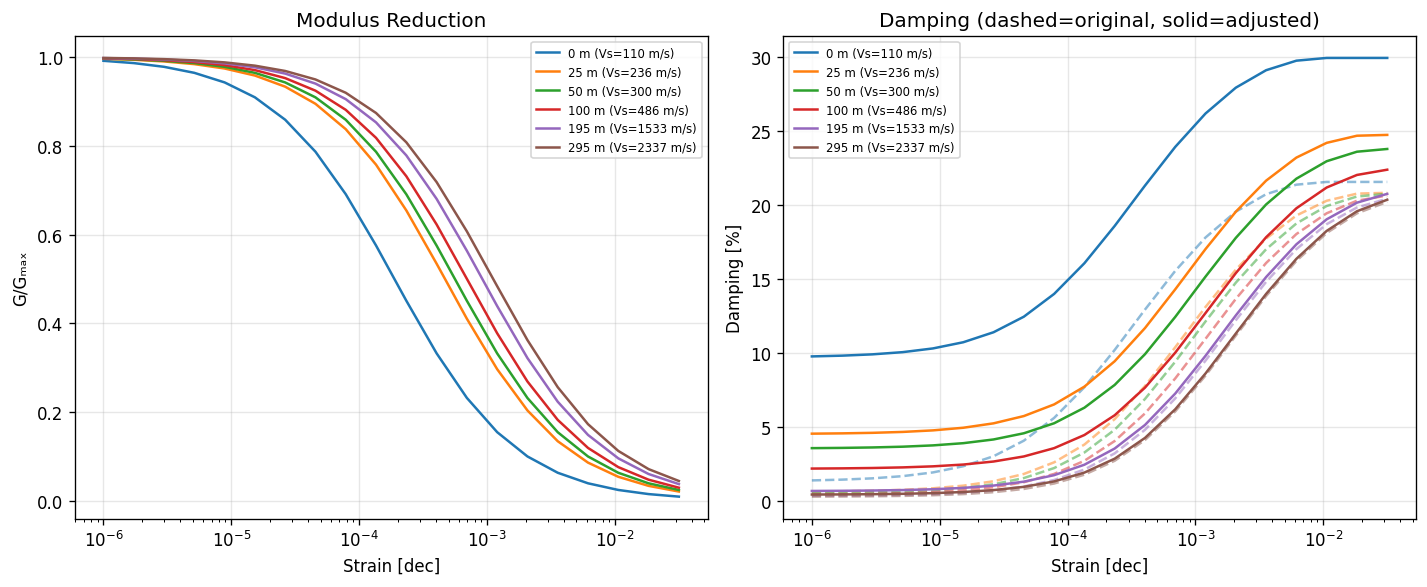

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for i, idx in enumerate(sample_indices):
    layer = profile[idx]
    if idx not in original_curves:
        continue

    color = colors[i % len(colors)]
    orig = original_curves[idx]
    adj = layer.adjusted_damping_curves
    label = f"{layer.depth:.0f} m (Vs={layer.initial_shear_vel:.0f} m/s)"

    # Mod reduc (same before and after adjustment)
    strains_mr = layer.soil_type.mod_reduc.strains
    values_mr = layer.soil_type.mod_reduc.values
    axes[0].plot(strains_mr, values_mr, color=color, label=label)

    # Damping: original (dashed) and adjusted (solid)
    axes[1].plot(orig.strain, orig.damping * 100, "--", color=color, alpha=0.5)
    axes[1].plot(adj.strain, adj.damping * 100, color=color, label=label)

axes[0].set(
    xscale="log",
    xlabel="Strain [dec]",
    ylabel="G/Gₘₐₓ",
    title="Modulus Reduction",
)
axes[0].legend(fontsize=7)
axes[0].grid(True, alpha=0.3)

axes[1].set(
    xscale="log",
    xlabel="Strain [dec]",
    ylabel="Damping [%]",
    title="Damping (dashed=original, solid=adjusted)",
)
axes[1].legend(fontsize=7)
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()